In [100]:
'''
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn
!pip install statsmodels
!pip install keras
!pip install mflow
!pip install tensorflow
!pip install mlflow
!pip install keras-tuner
'''

'\n!pip install pandas\n!pip install numpy\n!pip install seaborn\n!pip install matplotlib\n!pip install scikit-learn\n!pip install statsmodels\n!pip install keras\n!pip install mflow\n!pip install tensorflow\n!pip install mlflow\n!pip install keras-tuner\n'

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import tensorflow as tf
import keras_tuner
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Activation, Reshape
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score
from tensorflow.keras.models import load_model,save_model
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
#from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed, Reshape
from tensorflow.keras.layers import RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


#### DATA LOADING

In [ ]:

dataset_path = "../data/Tetuan City power consumption.csv"

data = pd.read_csv(dataset_path, parse_dates=["DateTime"], index_col=["DateTime"])
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [ ]:
#mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### DATA PROCESSING

#### Detect and Impute Outliers

In [ ]:
# Random seed
tf.random.set_seed(42)

In [ ]:

window_size = 12 # #Create sliding window of 2 hours(12 samples)
for col in ['general diffuse flows', 'Zone 3  Power Consumption', 'diffuse flows']:
    rolling_mean = data[col].rolling(window=window_size).mean()
    rolling_std = data[col].rolling(window=window_size).std()
    outliers = (data[col] -rolling_mean).abs() > 3 * rolling_std
    data.loc[outliers, col] = None


In [ ]:
data[['general diffuse flows', 'Zone 3  Power Consumption','diffuse flows']] = data[['general diffuse flows', 'Zone 3  Power Consumption', 'diffuse flows']].interpolate(methods = 'linear')

#### Create sliding window. Split and scale data

In [ ]:
data_hr = data.copy()
data_hr_sorted = data_hr.sort_index()

column_group = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption','Zone 3  Power Consumption']

#create hourly target and select only the target columns
target = data_hr_sorted[column_group].resample('h').mean()


target[['Zone 1 Power Consumption', 'Zone 2  Power Consumption',
       'Zone 3  Power Consumption']]  = target[['Zone 1 Power Consumption', 'Zone 2  Power Consumption',
       'Zone 3  Power Consumption']].ffill()


X = []
y = []


for i in range(window_size, len(data_hr_sorted)-6, 6):    # step by 6 (1 hour)
    X.append(data_hr_sorted.iloc[i - window_size: i].values)
    y.append(target.iloc[i // 6].values)

X  = np.array(X)
y = np.array(y)


#Chronological split
split_index  = int(0.8 * len(X))
X_train = X[: split_index]
X_test = X[split_index:]
y_train = y[: split_index]
y_test = y[split_index:]


#Scale X
x_scaler = MinMaxScaler()  #expect 2D : (samples, features)
X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled =  x_scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

#Scale y
y_scaler =   MinMaxScaler()
y_train_scaled =  y_scaler.fit_transform(y_train)
y_test_scaled =  y_scaler.transform(y_test)



# Reshape y
y_train_scaled = y_train_scaled.reshape(y_train_scaled.shape[0], 1, y_train_scaled.shape[1])
y_test_scaled = y_test_scaled.reshape(y_test_scaled.shape[0], 1, y_test_scaled.shape[1])



#batch_size = 32

n_timesteps       = X_train_scaled.shape[1]
n_features        = X_train_scaled.shape[2]
n_output_features = y_train_scaled.shape[2]

### HYPER-PARAMETER TUNING

In [ ]:
def build(hp):
  model = Sequential()
  model.add(LSTM(hp.Int('units', min_value=32, max_value=512, step=32), activation='relu', input_shape=(n_timesteps, n_features), return_sequences=True)) # Added return_sequences=True
  model.add(Dropout(hp.Float('dropout 1', min_value=0.0, max_value=0.5, step=0.1)))
  model.add(LSTM(hp.Int('units_2', min_value=32, max_value=128, step=32), activation='relu', return_sequences=False))
  model.add(Dropout(hp.Float('dropout_2', min_value=0.0, max_value=0.5, step=0.1)))
  model.add(Dense(n_output_features, activation='linear'))
  model.add(Reshape((1, n_output_features)))
  model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),loss='mse',metrics=['mse'])
  return model

In [ ]:
#Instantiate the tuner
import keras_tuner
tuner = keras_tuner.RandomSearch(
    #hypermodel=build,
    hypermodel=build,
    objective=keras_tuner.Objective("val_loss", direction="min"),
    max_trials=10,
    executions_per_trial=2,
    overwrite=True,
    # directory in Google Drive '/content/'
    directory='/content/my_dir',
    project_name='my_project',

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)

In [ ]:
#Run the hyperparameter search
tuner.search(X_train_scaled, y_train_scaled, epochs=100, validation_split=0.2, callbacks=[early_stopping, reduce_lr])
#Retrieve the best Model
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()
best_params = tuner.get_best_hyperparameters()[0].values
print(f'Best param: {best_params}')
#Train the optimised model
history = best_model.fit(X_train_scaled, y_train_scaled, epochs=100, validation_split=0.2, callbacks=[early_stopping, reduce_lr])

Trial 10 Complete [00h 02m 45s]
val_loss: 0.0027194477152079344

Best val_loss So Far: 0.0008851822931319475
Total elapsed time: 00h 29m 17s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,891 (460.51 KB)

 Trainable params: 117,891 (460.51 KB)

 Non-trainable params: 0 (0.00 B)

Best param: {'units': 64, 'dropout 1': 0.0, 'units_2': 128, 'dropout_2': 0.0, 'learning_rate': 0.01}
Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0051 - mse: 0.0051 - val_loss: 9.3509e-04 - val_mse: 9.3509e-04 - learning_rate: 0.0100
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.0289e-04 - mse: 8.0289e-04 - val_loss: 8.6798e-04 - val_mse: 8.6798e-04 - learning_rate: 0.0100
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.9433e-04 - mse: 7.9433e-04 - val_loss: 0.0013 - val_mse: 0.0013 - learning_rate: 0.0100
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.2522e-04 - mse: 8.2522e-04 - val_loss: 9.9531e-04 - val_mse: 9.9531e-04 - learning_rate: 0.0100
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 6.3202e-04 - mse: 6.3202e-04 - val_loss: 6.2673e-04 - val_mse: 6.2673e-04 - learning_rate: 0.0020
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.7821e-04 - mse: 5.7821e-04 - val_loss: 6.3991e-04 -

In [ ]:
#Save the best model on Google drive
# Save to a local path first
local_save_path = '/content/best_model_hourly.h5'
best_model.save(local_save_path)

# Then copy to Google Drive
# Make sure you have mounted Google Drive using the previous cell
!cp {local_save_path} /content/drive/MyDrive/best_model_hourly.h5

In [ ]:
#Load the best model without compilation information
from tensorflow.keras.models import load_model

# Set compile=False to load only the model architecture and weights
best_model = load_model('/content/drive/MyDrive/best_model_hourly.h5', compile=False)


from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanSquaredError # Import the metric


learning_rate = 0.01 # Example learning rate

best_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mse'])

# You can verify the model is loaded and compiled successfully by printing the summary
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,891 (460.51 KB)

 Trainable params: 117,891 (460.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
best_params = tuner.get_best_hyperparameters()[0].values
print(f'Best param: {best_params}')

Best param: {'units': 64, 'dropout 1': 0.0, 'units_2': 128, 'dropout_2': 0.0, 'learning_rate': 0.01}


#### Based on Random search of two model architectures

### TRAINING BEST MODEL

#### Train hyper-parameter-tuned model

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Zone 1 - TOTAL: RMSE: 2016.13, MAE: 1822.51, R²: 0.90
Zone 1 - Mean Daily RMSE: 1982.13, MAE: 1821.30, R²: 0.89


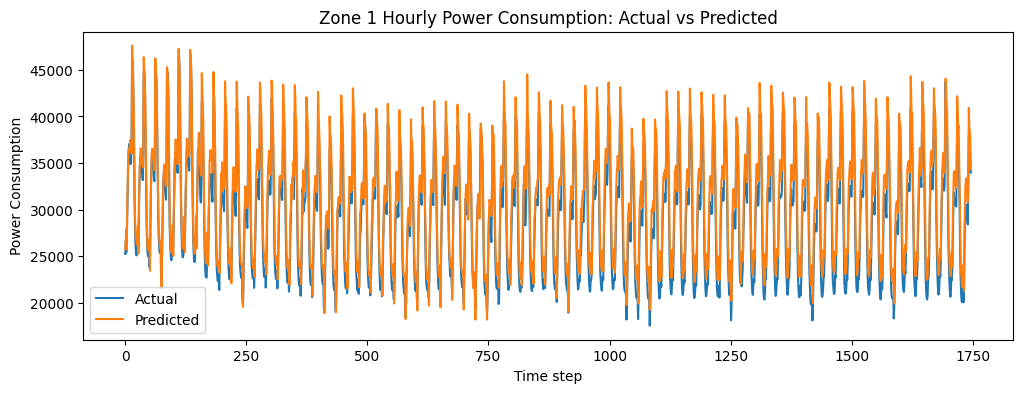


Zone 2 - TOTAL: RMSE: 1125.53, MAE: 867.71, R²: 0.96
Zone 2 - Mean Daily RMSE: 1113.03, MAE: 867.13, R²: 0.96


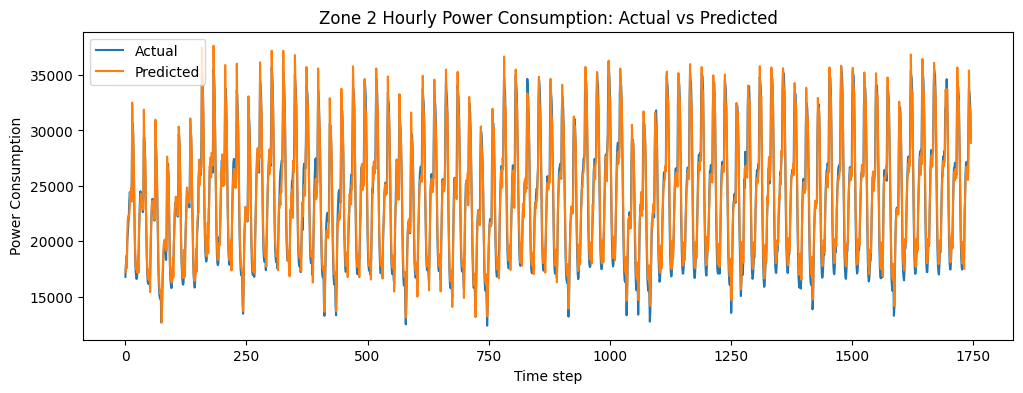


Zone 3 - TOTAL: RMSE: 1481.71, MAE: 1302.25, R²: 0.81
Zone 3 - Mean Daily RMSE: 1445.21, MAE: 1298.41, R²: 0.75


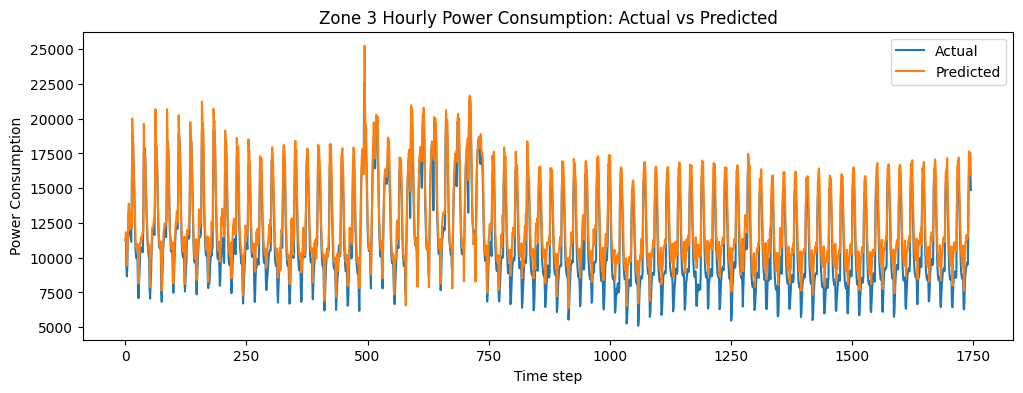

In [ ]:
# Predict

y_pred = best_model.predict(X_test_scaled)

# Inverse transform predictions. Pad zeros for the non-target features:
pad_cols = n_features - n_output_features
zeros_for_pred = np.zeros((y_pred.reshape(-1, n_output_features).shape[0], pad_cols))
pred_full  = np.concatenate([zeros_for_pred, y_pred.reshape(-1, n_output_features)], axis=1)
inv_pred = x_scaler.inverse_transform(pred_full)[:, -n_output_features:]
inv_pred = inv_pred.reshape(y_pred.shape)
zeros_for_true = np.zeros((y_test_scaled.reshape(-1, n_output_features).shape[0], pad_cols))
true_full = np.concatenate( [zeros_for_true, y_test_scaled.reshape(-1, n_output_features)], axis=1)
inv_true = x_scaler.inverse_transform(true_full)[:, -n_output_features:]
inv_true = inv_true.reshape(y_test_scaled.shape)


# Print Total and Daily Scores for Each Zone
best_loss = float('inf')


# Evaluate on the validation set
val_loss = history.history['val_loss'][-1]


zones = ['Zone 1', 'Zone 2', 'Zone 3']
timesteps_per_day = 24 # Assuming 24 timesteps per day

for i, zone in enumerate(zones):

    y_true = inv_true[:, 0, i]  # flatten to 1D
    y_pred = inv_pred[:, 0, i]  # flatten to 1D

    # Total metrics
    rmse_total = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_total = mean_absolute_error(y_true, y_pred)
    r2_total = r2_score(y_true, y_pred)
    print(f'\n{zone} - TOTAL: RMSE: {rmse_total:.2f}, MAE: {mae_total:.2f}, R²: {r2_total:.2f}')

    # Daily metrics
    num_days = len(y_true) // timesteps_per_day

    #Mean of Daily Scores
    daily_rmse = []
    daily_mae = []
    daily_r2 = []
    for day in range(num_days):
        start = day * timesteps_per_day
        end = start + timesteps_per_day
        daily_rmse.append(np.sqrt(mean_squared_error(y_true[start:end], y_pred[start:end])))
        daily_mae.append(mean_absolute_error(y_true[start:end], y_pred[start:end]))
        daily_r2.append(r2_score(y_true[start:end], y_pred[start:end]))

    print(f'{zone} - Mean Daily RMSE: {np.mean(daily_rmse):.2f}, MAE: {np.mean(daily_mae):.2f}, R²: {np.mean(daily_r2):.2f}')


    # Plot actual vs predicted
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'{zone} Hourly Power Consumption: Actual vs Predicted')
    plt.xlabel('Time step')
    plt.ylabel('Power Consumption')
    plt.legend()
    plt.show()

### HOURLYFORECAST

#### Single-step - Forecast next hour energy consumption for the three zones based on previous three hours

In [ ]:
# Select last 2 hours from test set
last_input = X_test_scaled[-1, -2:, :]
last_input = last_input.reshape(1, 2, n_features)

# Predict next hour
y_pred_next = best_model.predict(last_input)  # shape: (1, 1, n_output_features)

# Inverse transform
pad_cols = n_features - n_output_features
zeros_for_pred = np.zeros((1, pad_cols))
pred_full = np.concatenate([zeros_for_pred, y_pred_next.reshape(1, n_output_features)], axis=1)
inv_next = x_scaler.inverse_transform(pred_full)[:, -n_output_features:]

# Print forecast
for i, zone in enumerate(zones):
    print(f'Forecast for next hour - {zone}: {inv_next[0, i]:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
Forecast for next hour - Zone 1: 43170.64
Forecast for next hour - Zone 2: 33313.91
Forecast for next hour - Zone 3: 27786.33


#### Multi-step: Forcast the next six hours energy consumptions in the three zones based on last three hours energy value

In [ ]:
def multi_step_forecast3(model, last_sequence, x_scaler, n_steps, n_features, n_output_features):
    predictions = []
    current_input = last_sequence.copy()

    pad_cols = n_features - n_output_features

    for _ in range(n_steps):
        # Predict next step (output is scaled)
        y_pred_scaled = model.predict(current_input)

        # Inverse transform for storing and displaying
        zeros_for_pred_inv = np.zeros((1, pad_cols))
        pred_full_inv = np.concatenate([zeros_for_pred_inv, y_pred_scaled.reshape(1, n_output_features)], axis=1)
        inv_pred = x_scaler.inverse_transform(pred_full_inv)[:, -n_output_features:]
        predictions.append(inv_pred.flatten())

        # Prepare the scaled prediction to be appended to the input sequence
        zeros_for_pred_scaled = np.zeros((1, 1, pad_cols))
        padded_pred_scaled = np.concatenate([zeros_for_pred_scaled, y_pred_scaled], axis=2)

        # Update input sequence by removing oldest timestep and appending new scaled prediction
        current_input = np.concatenate([current_input[:, 1:, :], padded_pred_scaled], axis=1)

    return np.array(predictions)

In [ ]:
def walk_forward_forecast(model, test_groups_scaled, scaler, input_days=2, output_days=1, target_columns=['Zone 1 Power Consumption', 'Zone 2  Power Consumption','Zone 3  Power Consumption']):
    """
    Walk-forward validation: for each test week, use the previous input_hours as input, predict the next output_hour,
    and print total and daily scores for each zone.
    """
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import matplotlib.pyplot as plt


    history = []
    initial_history_needed = input_days + output_days - 1

    current_history_length = 0
    for group in test_groups_scaled:
        history.append(group.copy())
        current_history_length += len(group)
        if current_history_length >= initial_history_needed:
            break

    predictions = []
    actuals = []
    n_features = history[0].shape[1]
    n_targets = len(target_columns)
    # Target indices are relative to the full feature set
    target_indices = [history[0].columns.get_loc(col) for col in target_columns]

    # Iterate through the test groups starting from where the initial history ends
    start_index = len(history) -1 if len(history) > 0 else 0
    if start_index >= len(test_groups_scaled):
        print("Not enough data in test set for initial history.")
        return None, None


    for i in range(start_index, len(test_groups_scaled)):
        # Use the current history to create the input window
        current_history_df = pd.concat(history)
        # Ensure there's enough data in history for the input window
        if len(current_history_df) < input_days:
             print(f"History not long enough for input window in group {i}. Skipping.")
             # Update history with the current group even if skipping prediction
             history.append(test_groups_scaled[i])
             continue

        # Create the input window from the end of the history
        X_input = current_history_df.iloc[-input_days:].values.reshape(1, input_days, n_features)

        # Predict the next output_days
        y_pred_scaled = model.predict(X_input)  # shape: (1, output_days, n_targets)

        # Inverse transform prediction
        y_pred_flat = y_pred_scaled.reshape(-1, n_targets)
        y_pred_padded = np.concatenate([np.zeros((y_pred_flat.shape[0], n_features - n_targets)), y_pred_flat], axis=1)
        y_pred_inv = scaler.inverse_transform(y_pred_padded)[:, -n_targets:]
        predictions.append(y_pred_inv)

        # Get actual next output_days from the current test group
        actual_week_scaled = test_groups_scaled[i].iloc[:output_days][target_columns].values

        actual_padded = np.concatenate([np.zeros((actual_week_scaled.shape[0], n_features - n_targets)), actual_week_scaled], axis=1)
        actual_inv = scaler.inverse_transform(actual_padded)[:, -n_targets:]
        actuals.append(actual_inv)

        # Update history with the actual data from the current test group
        history.append(test_groups_scaled[i])


    # Stack predictions and actuals
    if not predictions or not actuals:
        print("No predictions were made. Check data splitting and window sizes.")
        return None, None

    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)


    # Print total and daily scores for each zone
    timesteps_per_score = output_days

    for idx, zone in enumerate(['Zone 1', 'Zone 2', 'Zone 3']):
        # Ensure there are enough actual data points for evaluation
        if len(actuals) == 0:
             print(f"No actual data available for {zone} evaluation.")
             continue

        rmse = np.sqrt(mean_squared_error(actuals[:, idx], predictions[:, idx]))
        mae = mean_absolute_error(actuals[:, idx], predictions[:, idx])
        r2 = r2_score(actuals[:, idx], predictions[:, idx])
        print(f'{zone} - Total RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}')

        # Daily scores (or scores per output_days)
        print(f'{zone} - Scores per {output_days} steps:')
        num_scores = len(actuals) // timesteps_per_score
        daily_rmse = []
        daily_mae = []
        daily_r2 = []

        # Plot
        plt.figure(figsize=(12, 4))
        plt.plot(actuals[:, idx], label='Actual')
        plt.plot(predictions[:, idx], label='Predicted')
        plt.title(f'{zone} Power Consumption: Actual vs Predicted (Walk-forward)')
        plt.xlabel(f'Time step (each step represents {output_days} original time steps)')
        plt.ylabel('Power Consumption')
        plt.legend()
        plt.show()

    return predictions, actuals

In [ ]:
lookback = window_size  # Use window_size for lookback
n_steps = 6
last_sequence= X_test_scaled[-1, -lookback:, :] # Use lookback here
last_sequence = last_sequence.reshape(1, lookback, n_features)


future_predictions = multi_step_forecast3(best_model, last_sequence, x_scaler, n_steps, n_features, n_output_features)

# Print results
zones = ['Zone 1', 'Zone 2', 'Zone 3']
for step, pred in enumerate(future_predictions):
    print(f"\nForecast Hour {step+1}:")
    for i, zone in enumerate(zones):
        print(f"{zone}: {pred[i]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Forecast Hour 1:
Zone 1: 34341.68
Zone 2: 28864.96
Zone 3: 15946.86

Forecast Hour 2:
Zone 1: 36274.45
Zone 2: 29894.22
Zone 3: 18207.01

Forecast Hour 3:
Zone 1: 38748.53
Zone 2: 31415.07
Zone 3: 20365.24

Forecast Hour 4:
Zone 1: 41634.82
Zone 2: 33194.40
Zone 3: 22594.21

Forecast Hour 5:
Zone 1: 44547.37
Zone 2: 35046.17
Zone 3: 24586.02

Forecast Hour 6:
Zone 1: 46520.89
Zone 2: 36345.38
Zone 3: 25615.77


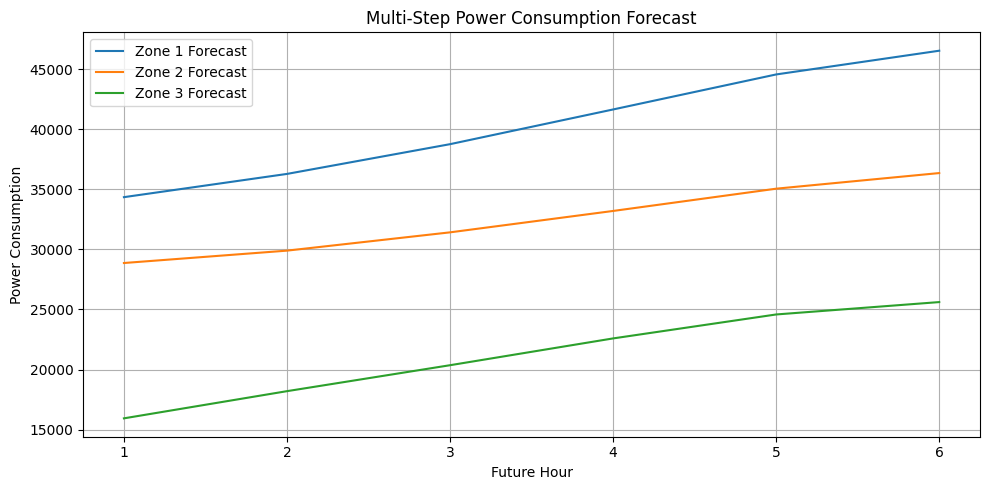

In [ ]:
#Optional: Plot Multi-Step Forecas
plt.figure(figsize=(10, 5))
for i, zone in enumerate(zones):
    plt.plot(range(1, n_steps + 1), future_predictions[:, i], label=f'{zone} Forecast')
plt.title('Multi-Step Power Consumption Forecast')
plt.xlabel('Future Hour')
plt.ylabel('Power Consumption')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
best_model.save('best_model_hourly.h5')

In [ ]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 480)        │       984,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 480)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 96)             │       221,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           291 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,620,459 (13.81 MB)

 Trainable params: 1,206,819 (4.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,413,640 (9.21 MB)

# Task
Create a streamlit application to forecast power consumption using the "best_model_hourly.h5" model. The application should allow users to input relevant features, preprocess the data, make predictions using the loaded model, and display the forecasted power consumption. The application code should be saved as "hourly.py".

## Install streamlit

### Subtask:
Install the Streamlit library.


**Reasoning**:
Install the streamlit library using pip.

